# 05 — Tier 2 Feature Extraction (Structure-Based)

**Goal**: Extract crystal structure features from CIF files for entries that have them.

These features capture:
- **Lattice geometry**: Cell volume, spaciousness, anisotropy, density
- **Symmetry**: Space group, crystal system, number of symmetry operations
- **Li coordination**: How Li sits in the structure — neighbors, bond distances, site geometry

Applied to `struct_train` (339 entries) and `struct_test` (69 entries).
Tier 1 composition features are included automatically.

**Prerequisites**: Run notebooks 01-03 first. CIF files in `cifs/` folder.

In [17]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from pymatgen.core import Structure, Element
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
import warnings
warnings.filterwarnings('ignore')

## Step 1: Define structural feature extraction

All features computed from atom positions in the CIF — no simulation, just geometry.

In [18]:
def extract_structure_features(cif_path):
    """Extract Tier 2 features from a CIF file."""
    try:
        struct = Structure.from_file(cif_path)
    except Exception:
        return None
    
    lattice = struct.lattice
    volume = lattice.volume
    n_atoms = len(struct)
    vol_per_atom = volume / n_atoms
    
    li_sites = [site for site in struct if 'Li' in site.species_string]
    n_li = len(li_sites)
    vol_per_li = volume / n_li if n_li > 0 else np.nan
    
    a, b, c = lattice.a, lattice.b, lattice.c
    ba_ratio = b / a
    ca_ratio = c / a
    density = struct.density
    
    try:
        sga = SpacegroupAnalyzer(struct, symprec=0.1)
        spacegroup_num = sga.get_space_group_number()
        crystal_system = sga.get_crystal_system()
        n_sym_ops = len(sga.get_symmetry_operations())
    except Exception:
        spacegroup_num = np.nan
        crystal_system = 'unknown'
        n_sym_ops = np.nan
    
    li_coord_numbers = []
    li_anion_distances = []
    li_li_distances = []
    anion_symbols = {'O', 'S', 'F', 'Cl', 'Br', 'I', 'N', 'Se', 'Te'}
    
    if n_li > 0:
        for li_site in li_sites:
            neighbors = struct.get_neighbors(li_site, r=4.0)
            
            anion_neighbors = [n for n in neighbors if any(a in n.species_string for a in anion_symbols)]
            
            if anion_neighbors:
                anion_neighbors.sort(key=lambda n: n.nn_distance)
                min_dist = anion_neighbors[0].nn_distance
                coord_shell = [n for n in anion_neighbors if n.nn_distance < min_dist * 1.5]
                
                li_coord_numbers.append(len(coord_shell))
                li_anion_distances.extend([n.nn_distance for n in coord_shell])
            
            li_neighbors = [n for n in neighbors if 'Li' in n.species_string]
            if li_neighbors:
                li_li_distances.extend([n.nn_distance for n in li_neighbors])
    
    avg_li_coord = np.mean(li_coord_numbers) if li_coord_numbers else np.nan
    avg_li_anion_dist = np.mean(li_anion_distances) if li_anion_distances else np.nan
    std_li_anion_dist = np.std(li_anion_distances) if len(li_anion_distances) > 1 else np.nan
    min_li_li_dist = np.min(li_li_distances) if li_li_distances else np.nan
    
    return {
        'cell_volume': volume,
        'vol_per_atom': vol_per_atom,
        'vol_per_li': vol_per_li,
        'ba_ratio': ba_ratio,
        'ca_ratio': ca_ratio,
        'density': density,
        'spacegroup_num': spacegroup_num,
        'n_sym_ops': n_sym_ops,
        'crystal_system': crystal_system,
        'avg_li_coord_num': avg_li_coord,
        'avg_li_anion_dist': avg_li_anion_dist,
        'std_li_anion_dist': std_li_anion_dist,
        'min_li_li_dist': min_li_li_dist,
    }

## Step 2: Extract features for struct datasets

In [19]:
def featurize_structures(df, label):
    """Extract structural features for all entries with CIFs."""
    print(f"Extracting structural features for {label} ({len(df)} entries)...")
    
    features = []
    failed = []
    for i, (_, row) in enumerate(df.iterrows()):
        if i % 50 == 0 and i > 0:
            print(f"  Processed {i}/{len(df)}...")
        
        cif_path = f"cifs/{row['id']}.cif"
        if not os.path.exists(cif_path):
            failed.append(row['id'])
            features.append({})
            continue
        
        feat = extract_structure_features(cif_path)
        if feat is None:
            failed.append(row['id'])
            features.append({})
        else:
            features.append(feat)
    
    feat_df = pd.DataFrame(features)
    
    if failed:
        print(f"  WARNING: {len(failed)} CIFs failed to parse")
    
    # One-hot encode crystal_system
    if 'crystal_system' in feat_df.columns:
        dummies = pd.get_dummies(feat_df['crystal_system'], prefix='csys')
        feat_df = pd.concat([feat_df.drop('crystal_system', axis=1), dummies], axis=1)
    
    print(f"  Extracted {len(feat_df.columns)} structural features")
    return feat_df

# Load struct datasets
struct_train = pd.read_csv('struct_train.csv')
struct_test = pd.read_csv('struct_test.csv')

# Extract
struct_train_feat = featurize_structures(struct_train, 'struct_train')
struct_test_feat = featurize_structures(struct_test, 'struct_test')

Extracting structural features for struct_train (339 entries)...
  Processed 50/339...
  Processed 100/339...
  Processed 150/339...
  Processed 200/339...
  Processed 250/339...
  Processed 300/339...
  Extracted 20 structural features
Extracting structural features for struct_test (69 entries)...
  Processed 50/69...
  Extracted 19 structural features


## Step 3: Combine with Tier 1 composition features

The structure model gets BOTH composition features (Tier 1) and structural features (Tier 2).

In [20]:
# Load Tier 1 features for struct datasets
struct_train_t1 = pd.read_csv('struct_train_features.csv')
struct_test_t1 = pd.read_csv('struct_test_features.csv')

# Separate Tier 1 features (drop meta columns)
meta_cols = ['id', 'composition', 'log_conductivity']
t1_feature_cols = [c for c in struct_train_t1.columns if c not in meta_cols]

t1_train = struct_train_t1[t1_feature_cols]
t1_test = struct_test_t1[t1_feature_cols]

# Combine Tier 1 + Tier 2
combined_train = pd.concat([t1_train.reset_index(drop=True), struct_train_feat.reset_index(drop=True)], axis=1)
combined_test = pd.concat([t1_test.reset_index(drop=True), struct_test_feat.reset_index(drop=True)], axis=1)

print(f"Tier 1 features: {len(t1_feature_cols)}")
print(f"Tier 2 features: {len(struct_train_feat.columns)}")
print(f"Combined features: {len(combined_train.columns)}")
print(f"\nAll feature columns:")
print(combined_train.columns.tolist())

Tier 1 features: 16
Tier 2 features: 20
Combined features: 36

All feature columns:
['li_count', 'mean_electronegativity', 'anion_electronegativity', 'cation_anion_en_diff', 'mean_ionic_radius', 'anion_ionic_radius', 'radius_std', 'anion_polarizability', 'mean_atomic_mass', 'n_elements', 'mean_atomic_number', 'anion_halide', 'anion_mixed', 'anion_other', 'anion_oxide', 'anion_sulfide', 'cell_volume', 'vol_per_atom', 'vol_per_li', 'ba_ratio', 'ca_ratio', 'density', 'spacegroup_num', 'n_sym_ops', 'avg_li_coord_num', 'avg_li_anion_dist', 'std_li_anion_dist', 'min_li_li_dist', 'csys_cubic', 'csys_hexagonal', 'csys_monoclinic', 'csys_orthorhombic', 'csys_tetragonal', 'csys_triclinic', 'csys_trigonal', 'csys_unknown']


## Step 4: Inspect and check for issues

In [21]:
# Check NaNs
nan_counts = combined_train.isna().sum()
print("=== NaN counts per feature ===")
print(nan_counts[nan_counts > 0] if nan_counts.any() else "No NaN values")

# Stats for structural features
print(f"\n=== Structural feature stats ===")
struct_cols = struct_train_feat.select_dtypes(include=[np.number]).columns.tolist()
display(struct_train_feat[struct_cols].describe().round(3))

# Crystal system distribution
csys_cols = [c for c in combined_train.columns if c.startswith('csys_')]
if csys_cols:
    print(f"\n=== Crystal system distribution (train) ===")
    for col in csys_cols:
        print(f"  {col}: {int(combined_train[col].sum())} entries")

=== NaN counts per feature ===
vol_per_li            7
spacegroup_num        1
n_sym_ops             1
avg_li_coord_num     15
avg_li_anion_dist    15
std_li_anion_dist    15
min_li_li_dist       44
dtype: int64

=== Structural feature stats ===


,cell_volume,vol_per_atom,vol_per_li,ba_ratio,ca_ratio,density,spacegroup_num,n_sym_ops,avg_li_coord_num,avg_li_anion_dist,std_li_anion_dist,min_li_li_dist
count,339.000,339.000,332.000,339.000,339.000,339.000,338.000,338.000,324.000,324.000,324.000,295.000
mean,920.808,12.133,52.956,1.048,1.348,3.359,136.059,43.388,5.501,2.345,0.231,2.084
std,599.768,4.137,55.426,0.356,0.634,1.449,85.035,48.825,2.652,0.314,0.142,1.147
min,39.007,5.713,7.440,0.193,0.340,0.725,1.000,1.000,1.000,1.542,0.000,0.036
25%,352.728,9.587,18.662,1.000,1.000,2.191,60.250,8.000,4.000,2.091,0.135,0.865
50%,961.681,11.031,31.045,1.000,1.000,2.927,167.000,17.000,5.000,2.316,0.230,2.284
75%,1210.167,13.362,56.701,1.000,1.693,4.599,216.000,96.000,6.000,2.561,0.328,2.974
max,2242.587,32.784,260.816,4.467,5.248,7.012,230.000,192.000,20.000,3.338,0.606,3.931



=== Crystal system distribution (train) ===
  csys_cubic: 128 entries
  csys_hexagonal: 11 entries
  csys_monoclinic: 46 entries
  csys_orthorhombic: 51 entries
  csys_tetragonal: 42 entries
  csys_triclinic: 20 entries
  csys_trigonal: 40 entries
  csys_unknown: 1 entries


In [33]:
# Fair comparison: train composition-only model on ONLY the 323 struct entries
# and evaluate on the SAME 68 test entries

# Composition features only, same training data
comp_only_cols = [c for c in feature_cols if c in ['li_count', 'mean_electronegativity', 
    'anion_electronegativity', 'cation_anion_en_diff', 'mean_ionic_radius', 
    'anion_ionic_radius', 'radius_std', 'anion_polarizability', 'mean_atomic_mass', 
    'n_elements', 'mean_atomic_number', 'anion_halide', 'anion_mixed', 'anion_other', 
    'anion_oxide', 'anion_sulfide']]

model_comp = GradientBoostingRegressor(
    n_estimators=500, max_depth=4, learning_rate=0.05,
    subsample=0.8, min_samples_leaf=5, random_state=42
)
model_comp.fit(clean_train[comp_only_cols].values, y_train)
y_pred_comp = model_comp.predict(clean_test[comp_only_cols].values)
mae_comp = mean_absolute_error(y_test, y_pred_comp)

# Structure features (Tier 1 + Tier 2), same data
struct_cols = comp_only_cols + ['cell_volume', 'vol_per_li', 'density', 
    'spacegroup_num', 'n_sym_ops', 'avg_li_coord_num', 'avg_li_anion_dist']
model_struct = GradientBoostingRegressor(
    n_estimators=500, max_depth=4, learning_rate=0.05,
    subsample=0.8, min_samples_leaf=5, random_state=42
)
model_struct.fit(clean_train[struct_cols].values, y_train)
y_pred_struct = model_struct.predict(clean_test[struct_cols].values)
mae_struct = mean_absolute_error(y_test, y_pred_struct)

print(f"FAIR COMPARISON (same 323 train, same 68 test):")
print(f"  Composition only ({len(comp_only_cols)} features): MAE = {mae_comp:.3f}")
print(f"  + Structure      ({len(struct_cols)} features):    MAE = {mae_struct:.3f}")
print(f"  Difference: {mae_comp - mae_struct:.3f}")

FAIR COMPARISON (same 323 train, same 68 test):
  Composition only (16 features): MAE = 2.068
  + Structure      (23 features):    MAE = 1.953
  Difference: 0.115


In [34]:
# Load the full comp test results
comp_test_full = pd.read_csv('comp_test_features.csv')
has_cif = comp_test_full['id'].isin(set(f.replace('.cif','') for f in os.listdir('cifs') if f.endswith('.cif')))

print(f"Test entries WITH CIF: {has_cif.sum()}, mean |log_cond|: {comp_test_full[has_cif]['log_conductivity'].mean():.2f}")
print(f"Test entries NO CIF:   {(~has_cif).sum()}, mean |log_cond|: {comp_test_full[~has_cif]['log_conductivity'].mean():.2f}")

Test entries WITH CIF: 68, mean |log_cond|: -5.83
Test entries NO CIF:   52, mean |log_cond|: -4.13


## Step 5: Correlation with conductivity

Structural feature correlations with log(conductivity):
min_li_li_dist      -0.492
vol_per_li          -0.196
avg_li_coord_num    -0.134
density             -0.130
ba_ratio            -0.124
vol_per_atom         0.034
ca_ratio             0.039
n_sym_ops            0.193
std_li_anion_dist    0.208
cell_volume          0.332
avg_li_anion_dist    0.342
spacegroup_num       0.346
dtype: float64


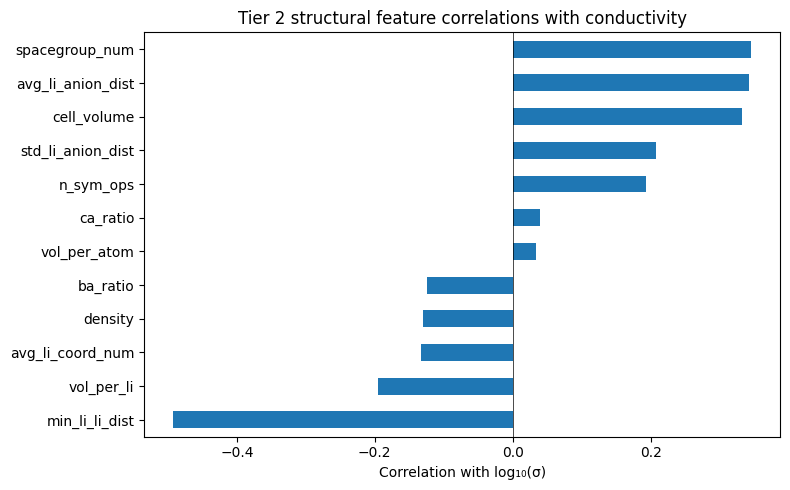

In [22]:
# Correlations — structural features only (Tier 1 we already checked)
target = struct_train['log_conductivity']

struct_numeric = struct_train_feat.select_dtypes(include=[np.number])
correlations = struct_numeric.corrwith(target).sort_values()

print("Structural feature correlations with log(conductivity):")
print(correlations.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
correlations.plot(kind='barh', ax=ax)
ax.set_xlabel('Correlation with log₁₀(σ)')
ax.set_title('Tier 2 structural feature correlations with conductivity')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## Step 6: Train structure-based model and compare

Same GBT model, but now with Tier 1 + Tier 2 features on the struct dataset.

In [23]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Prepare data
feature_cols = combined_train.columns.tolist()

all_data_train = pd.concat([
    struct_train[['id','composition','log_conductivity']].reset_index(drop=True),
    combined_train.reset_index(drop=True)
], axis=1)
all_data_test = pd.concat([
    struct_test[['id','composition','log_conductivity']].reset_index(drop=True),
    combined_test.reset_index(drop=True)
], axis=1)

# Align columns — add missing columns as 0, drop extra columns
for col in feature_cols:
    if col not in all_data_test.columns:
        all_data_test[col] = 0
all_data_test = all_data_test[all_data_train.columns]

# Drop NaNs
clean_train = all_data_train.dropna(subset=feature_cols)
clean_test = all_data_test.dropna(subset=feature_cols)
print(f"After dropping NaNs: {len(clean_train)} train, {len(clean_test)} test")

X_train = clean_train[feature_cols].values
y_train = clean_train['log_conductivity'].values
X_test = clean_test[feature_cols].values
y_test = clean_test['log_conductivity'].values

# Train
model = GradientBoostingRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_leaf=5,
    random_state=42
)

# CV first
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
cv_mae = -cv_scores
print(f"\n5-fold CV MAE: {cv_mae.mean():.3f} ± {cv_mae.std():.3f}")

# Train and evaluate on test set
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n{'='*55}")
print(f"  COMPARISON: Composition-only vs Structure-based")
print(f"{'='*55}")
print(f"  Composition-only (829 train):  MAE = 1.144")
print(f"  Structure-based  ({len(clean_train)} train):  MAE = {mae:.3f}")
print(f"  OBELiX baseline:               MAE = ~0.85")
print(f"{'='*55}")
print(f"  Structure model RMSE: {rmse:.3f}")
print(f"  Structure model R²:   {r2:.3f}")
if mae < 1.144:
    print(f"  ✓ Structure model beats composition-only by {1.144 - mae:.3f}")
if mae < 0.85:
    print(f"  ✓ BEATING OBELiX baseline by {0.85 - mae:.3f}")

After dropping NaNs: 287 train, 64 test

5-fold CV MAE: 1.594 ± 0.277

  COMPARISON: Composition-only vs Structure-based
  Composition-only (829 train):  MAE = 1.144
  Structure-based  (287 train):  MAE = 1.781
  OBELiX baseline:               MAE = ~0.85
  Structure model RMSE: 2.343
  Structure model R²:   0.351


## Step 7: Parity plot and feature importance

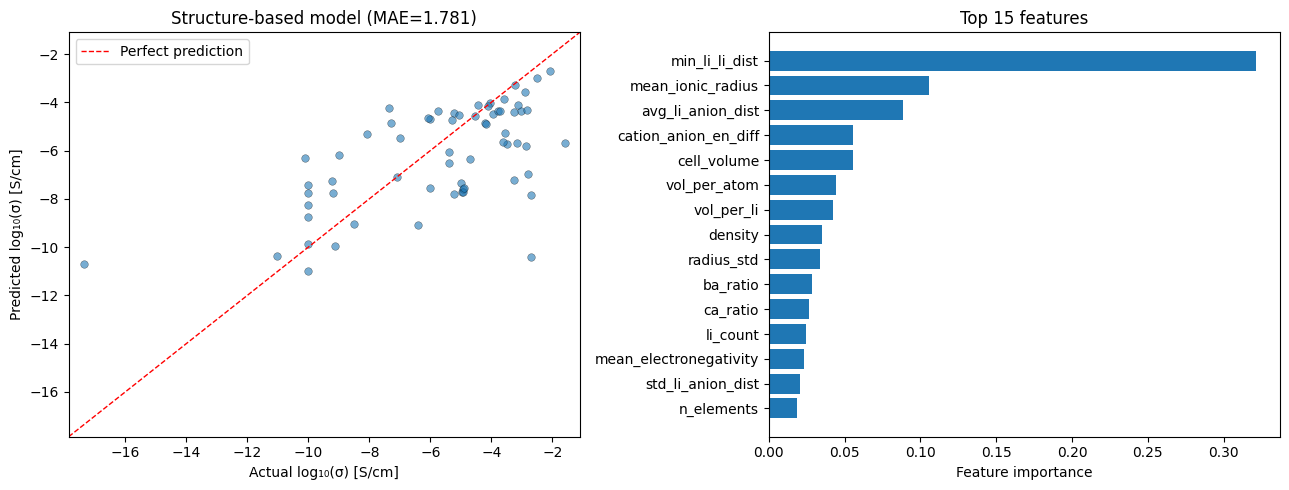

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Parity plot
ax = axes[0]
ax.scatter(y_test, y_pred, alpha=0.6, s=30, edgecolors='black', linewidths=0.3)
lims = [min(y_test.min(), y_pred.min()) - 0.5, max(y_test.max(), y_pred.max()) + 0.5]
ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
ax.set_xlabel('Actual log₁₀(σ) [S/cm]')
ax.set_ylabel('Predicted log₁₀(σ) [S/cm]')
ax.set_title(f'Structure-based model (MAE={mae:.3f})')
ax.legend()
ax.set_xlim(lims)
ax.set_ylim(lims)

# Feature importance
ax = axes[1]
importances = model.feature_importances_
sorted_idx = np.argsort(importances)[-15:]  # top 15
ax.barh(range(len(sorted_idx)), importances[sorted_idx])
ax.set_yticks(range(len(sorted_idx)))
ax.set_yticklabels([feature_cols[i] for i in sorted_idx])
ax.set_xlabel('Feature importance')
ax.set_title('Top 15 features')

plt.tight_layout()
plt.show()

## Step 8: Save

In [25]:
# Save combined feature matrices
save_train = pd.concat([
    struct_train[['id','composition','log_conductivity']].reset_index(drop=True),
    combined_train.reset_index(drop=True)
], axis=1)
save_test = pd.concat([
    struct_test[['id','composition','log_conductivity']].reset_index(drop=True),
    combined_test.reset_index(drop=True)
], axis=1)

save_train.to_csv('struct_train_t1t2_features.csv', index=False)
save_test.to_csv('struct_test_t1t2_features.csv', index=False)

print("Saved:")
print(f"  struct_train_t1t2_features.csv ({len(save_train)} × {len(combined_train.columns)} features)")
print(f"  struct_test_t1t2_features.csv  ({len(save_test)} × {len(combined_test.columns)} features)")
print("\n✓ Tier 1+2 features done.")

Saved:
  struct_train_t1t2_features.csv (339 × 36 features)
  struct_test_t1t2_features.csv  (69 × 35 features)

✓ Tier 1+2 features done.
